In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

#### Навигация по исследованию
>* [Часть 1: Календарный когортный анализ и расчет Retention Rate](#task-1)
>* [Часть 2: Оценка наличия Product-Market Fit (PMF)](#task-2)
>* [Часть 3: Декомпозиция и визуализация бизнес-метрик](#task-3)
>* [Часть 4: Приоритизация бэклога разработки по фреймворку ICE](#task-4)
>* [Часть 5: Проектирование архитектуры и метрик A/B-теста](#task-5)

>* [Итоговый аналитический отчет для менеджмента](#final-report)


In [2]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')

<a id="task-1"></a>
### Часть 1: Оценка месячного retention в оформление заказа с помощью когортного анализа.

#### 1.1 Исследовать датасет и определить, какой вид заказа будет учитываться в retention


In [3]:
# для оценки месячного ретеншена мне понадобятся данные даты заказы и айди юзера. Использую дф orders. 
# так как в данных у нас есть информация об уникальном юзере 
# у которого может быть нескольоко кастомер айди, есть смыл создать дф с датой доставленных заказов, кастомер айди, 
# и примерджить к кастомер айди уникальные кастомер айди. и дальше рплотать с этим дф. 

In [4]:
# создаю датафрейм
df = orders[orders.order_status=='delivered'][['customer_id','order_purchase_timestamp']]

In [5]:
# мерджу уникальный катомер айди, чтобы получить реальный ретеншен, 
# так как на один customer_unique_id может приходится несколько customer_id

df = df.merge(customers[['customer_id', 'customer_unique_id']], on = 'customer_id', how = 'left')
# df.head()

In [6]:
# перефожу дату в нужный формат и создаю колонки с периодами дат

df['order_purchase_timestamp']= pd.to_datetime(df.order_purchase_timestamp)
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_day'] = df['order_purchase_timestamp'].dt.to_period('D')
# df.head(3)

In [7]:
# для каждого пользователя выделяю его когорту. ищу минимальное время дейсвие для него.
# назову его chogort и first_order_day. перевуду в период согасно названию. 
df['chogort'] = df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
df['first_order_day'] = df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')
# df.head()

In [8]:
# тепрь для каждого заказа клиента у меня есть вермя первого заказа. 
# значит я могу посчитать на какой месяц был совершен заказа после первого оформления
# для этог вычту из дня заказа день первого заказа. разделю это на 30 и возьму целую часть

df['period_number_month'] =np.floor((df.order_day - df.first_order_day).apply(lambda x: x.n) / 30)
# df.head()

In [9]:
# теперь собираем данные по схеме -  когорта, месяц возвращаемости количесво заказов
df_chogort = (
    df.groupby(['chogort', 'period_number_month'])
    .agg(n_customers =('customer_unique_id','nunique'))
    .reset_index())
# df_chogort.head()

In [10]:
# разверну таблицу, чтоб провети когортный анализ
df_pivot = df_chogort.pivot(index = 'chogort', columns = 'period_number_month', values = 'n_customers')
# df_pivot

#### 1.2 Построить месячный retention

In [11]:
# подсчитаем размеры когорт, для этого возьмем значения первого столбца. iloc[строка,столбец]
chogort_size = df_pivot.iloc[:,0]

In [12]:
# подситчаем по месячным периодам ретеншен. для этого раздлим значения периодов на размер когорты. 
retention_matrix = df_pivot.div(chogort_size, axis = 0)
# retention_matrix

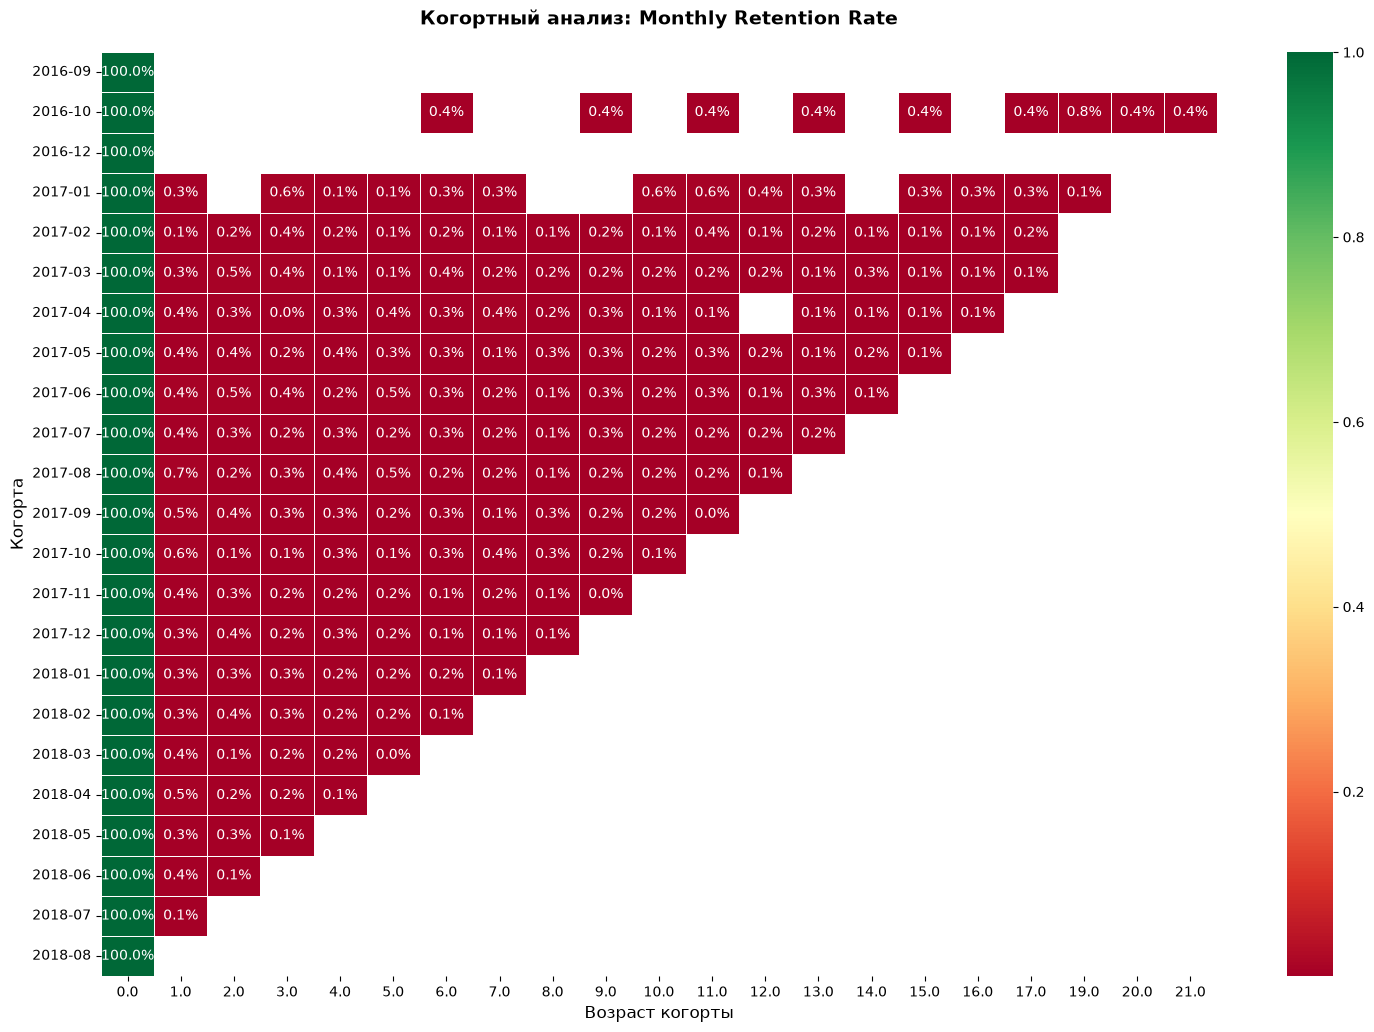

In [13]:
# 1. Задаем размер картинки (ширина, высота в дюймах)
plt.figure(figsize=(18, 12))

# 2. Строим сам хитмап
sns.heatmap(
    retention_matrix,  # Твоя готовая матрица с процентами
    annot=True,  # Включает отображение ЦИФР внутри ячеек (True - показывать, False - скрыть)
    fmt='.1%',  # ФОРМАТ ЧИСЕЛ: превращает 0.015 в красивое "1.5%" (один знак после запятой)
    cmap='RdYlGn',  # ЦВЕТОВАЯ ПАЛИТРА
    linewidths=0.5  # Микро-сетка между ячейками, чтобы косынка не сливалась
)

# 3. Наводим красоту
plt.title('Когортный анализ: Monthly Retention Rate', fontsize=14,
        fontweight="bold",
        pad=20)
plt.xlabel('Возраст когорты', fontsize=12)
plt.ylabel('Когорта', fontsize=12)


# plt.savefig('Когортный_анализ_Monthly_Retention_Rate.png', dpi=300, bbox_inches='tight')

plt.show()



#### 1.3 Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)

In [14]:
# считаю медианный retention 1-го месяца
retention_first_month = retention_matrix.iloc[:,1].median().round(4)
retention_first_month

np.float64(0.0035)

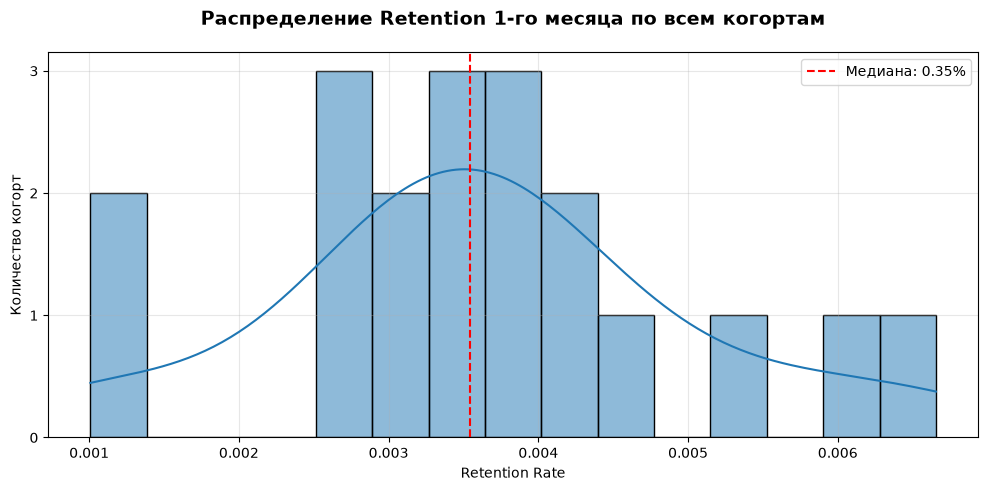

In [15]:


# визуализирую медиану и распределение ретеншнеа в когортах для 1-ого месяца
plt.figure(figsize=(12, 5))

# Строим график распределения для 1-го месяца

sns.histplot(x = retention_matrix.iloc[:,1],bins = 15, kde=True)

# Рисуем вертикальную линию на уровне медианы
plt.axvline(retention_matrix.iloc[:,1].median(), 
            color='red', 
            linestyle='--', 
            label=f'Медиана: {retention_matrix.iloc[:,1].median():.2%}')

plt.title('Распределение Retention 1-го месяца по всем когортам',
         fontsize=14,
        fontweight="bold",
        pad=20)
plt.xlabel('Retention Rate')
plt.ylabel('Количество когорт')

plt.yticks(range(0,4))
# plt.xticks(np.arange(0,0.007,0.0005))


plt.grid(alpha = 0.3)

plt.legend()

# plt.savefig('Retention_1_месяца.png', dpi=300, bbox_inches='tight')

plt.show()


#### 1.4 Найти когорту с самым высоким retention на 3-й месяц.

In [16]:
max_retention_3_month_chogort = retention_matrix.iloc[:,3].idxmax()
max_retention_3_month_value = retention_matrix.iloc[:,3].max()

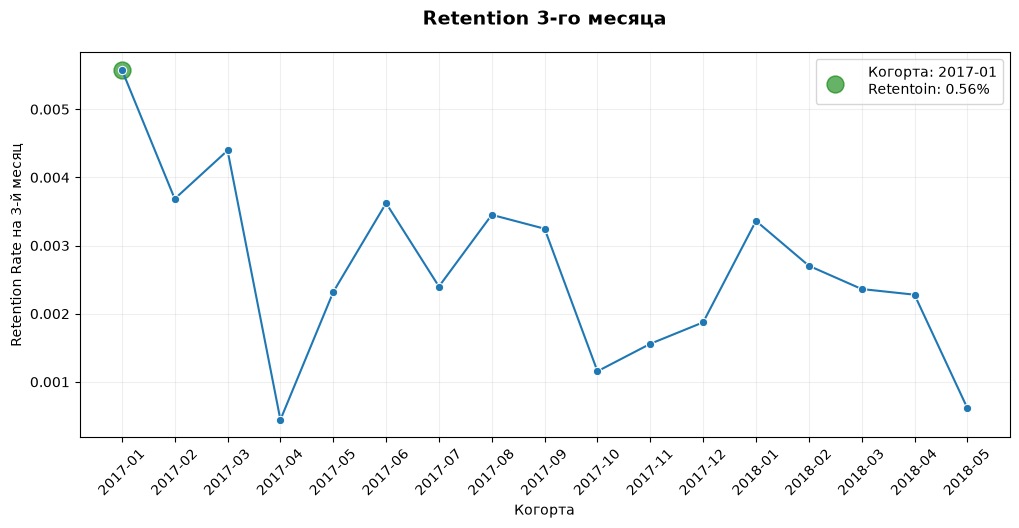

In [17]:
plt.figure(figsize = (12,5))
sns.lineplot(y = retention_matrix.iloc[:,3], x = retention_matrix.index.astype(str), marker = 'o')

plt.xticks(rotation = 45)
plt.grid(alpha = 0.2)

plt.title('Retention 3-го месяца',
         fontsize=14,
        fontweight="bold",
        pad=20)

plt.xlabel('Когорта')
plt.ylabel('Retention Rate на 3-й месяц')

plt.scatter(x = str(max_retention_3_month_chogort), 
            y = max_retention_3_month_value, 
            color = 'green',
            s = 150,
            alpha = 0.6,
           label = f'''  Когорта: {str(max_retention_3_month_chogort)}
  Retentoin: {max_retention_3_month_value:.2%}'''
           )
plt.legend()

# plt.savefig('Retention_3_месяца.png', dpi=300, bbox_inches='tight')

plt.show()

<a id="task-2"></a>
### Часть 2: Оценка наличия Product-Market Fit у маркетплейса.


#### 2.1 Оценка наличия product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.

#### 1. Оценка наличия Product/Market Fit

Когортный анализ показывает **очень низкую возвращаемость пользователей**: большинство клиентов не совершает повторный заказ в следующие месяцы. На доступном горизонте наблюдения выраженного плато retention не формируется.

Это сильный сигнал проблемы с удержанием и основание для дополнительной проверки гипотезы о наличии Product/Market Fit. При этом только по retention нельзя однозначно доказать полное отсутствие PMF — для такого вывода потребовались бы дополнительные данные о спросе, удовлетворенности пользователей, юнит-экономике и повторном использовании продукта.

In [18]:
# определим 5 наиболее крупных когорт
top_5_cohorts_name = ((list(chogort_size
                   .sort_values(ascending = False).
                   reset_index()
                   .head(5)['chogort']
                   .astype(str))))
# top_5_cohorts_name

In [19]:
# возьмем из общей таблицы дынные только 5 выбранных когорт
top_5_cohorts = retention_matrix[retention_matrix.index.astype(str).isin(top_5_cohorts_name)].reset_index()

In [20]:
# развернем таблицу для построения графика
top_5_cohorts = top_5_cohorts.melt(id_vars ='chogort',
                  var_name = 'period_number_month',
                  value_name = 'retantion_rate')
top_5_cohorts['period_number_month'] = top_5_cohorts['period_number_month'].astype(float)
top_5_cohorts['retantion_rate'] = top_5_cohorts['retantion_rate'].astype(float)

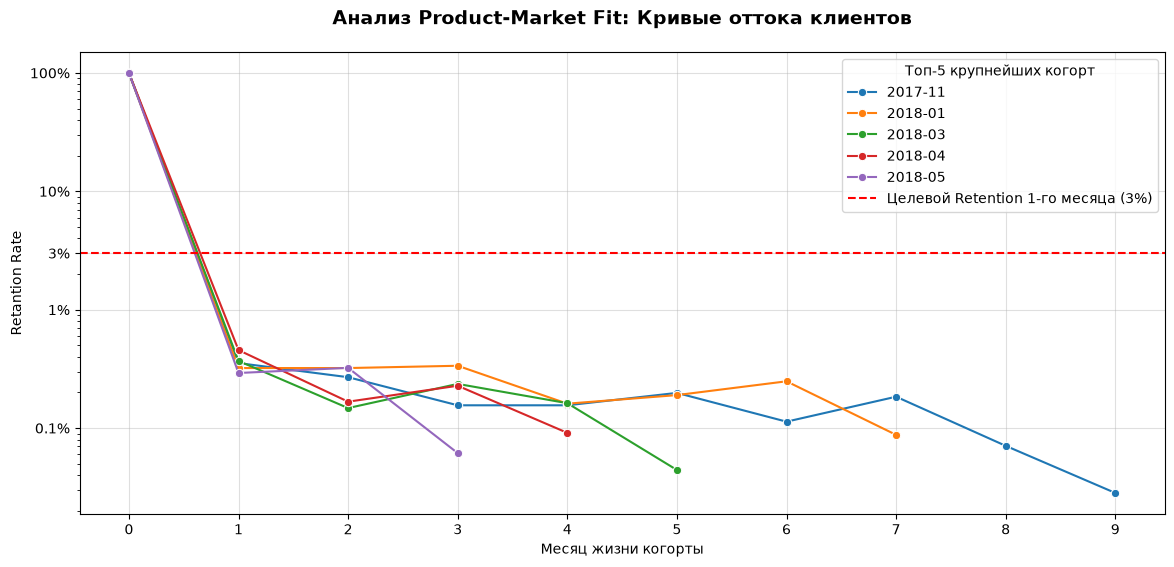

In [21]:
# построим лайнплот и логарифмируем данные по оси Y для наглядности
plt.figure(figsize = (14,6))

sns.lineplot(
    data = top_5_cohorts, 
    x = 'period_number_month', 
    y ='retantion_rate', 
    hue = 'chogort',
    marker = 'o',
    )

plt.yscale('log')
plt.yticks([1.0, 0.1, 0.03, 0.01, 0.001], ['100%','10%','3%','1%','0.1%'])
plt.xticks(range(0,10,1))

plt.title(
    "Анализ Product-Market Fit: Кривые оттока клиентов",
    fontsize=14,
    fontweight="bold",
    pad=20)

plt.xlabel('Месяц жизни когорты')
plt.ylabel('Retantion Rate')

plt.axhline(0.03, 
            linestyle = '--', 
            color = 'red', 
            label = 'Целевой Retention 1-го месяца (3%)')

plt.grid(alpha = 0.4)
plt.legend(title = 'Топ-5 крупнейших когорт')

# plt.savefig('Кривые_оттока_клиентов.png', dpi=300, bbox_inches='tight')

plt.show()

#### 2. Пояснение позиции и аргументация на основе данных

Одним из полезных сигналов при оценке PMF является форма кривой удержания: если через несколько периодов она выходит на устойчивое плато, это может говорить о наличии ядра пользователей, которые продолжают пользоваться продуктом.

В нашем случае Retention 1-го месяца (Monthly Retention) для пяти крупнейших когорт составляет менее 1%. На графике не видно выраженного стабилизационного плато: после первого заказа доля возвращающихся пользователей остается очень низкой.

Поэтому на основании доступных данных можно говорить о **проблеме с удержанием и повторными покупками**. Это не является самостоятельным доказательством отсутствия PMF, но требует дополнительного исследования причин оттока и пользовательского опыта.

#### 3. На чём маркетплейс должен сконцентрироваться в ближайшее время?

С учётом низкого удержания маркетплейсу стоит осторожно относиться к масштабированию и сначала подробнее исследовать причины оттока клиентов. Для этого продуктовой команде можно запустить цикл проверки гипотез и провести аудит ключевых точек отказа:
* **Логистика**: анализ SLA доставки и работы курьерских служб;
* **Продукт**: технический аудит платформы и UX-анализ интерфейсов;
* **Рынок**: анализ ассортимента и факторов, влияющих на повторную покупку.

Внедрение системы оценивания заказов и доставки, а также исследование клиентского опыта позволят собрать дополнительные данные для проверки этих гипотез.

<a id="task-3"></a>
### Часть 3: Декомпозиция и визуализация бизнес-метрик. 

Определение 5 основных метрик, на которых продакт может сконцентрироваться, чтобы оценивать динамику продукта и искать точки роста.

1. Рост объема продаж: количество доставленных заказов и общий оборот в деньгах (GMV) по месяцам.
2. Объем активной аудитории: количество уникальных клиентов с доставленными заказами за месяц (MAU).
3. Заинтересованность новых клиентов: количество новых пользователей/установок приложения (New Users / Installs).
4. Вовлеченность в продолжение использования: среднее количество заказов на одного пользователя (Purchase Frequency).
5. Монетизация пользователя: суммарная выручка на одного уникального пользователя за доступный период наблюдения. В учебном задании показатель используется как приближение LTV, но не является прогнозным LTV.

*Расчет и Визуализация выбранных метрик*

In [22]:
# необхожимо собрать датафрейм с досталвенными заказми, статусом, уникальным юзер айди, юзер айди, датой (например, доставка), цена одого айтема в заказе, количесвом айтемов в заказе.
df_metrics = (order_items
              .merge
              (orders[orders.order_status == 'delivered']
               [['order_id','customer_id','order_delivered_customer_date']], on = 'order_id', how = 'inner'))

df_metrics = df_metrics.merge(customers[['customer_id','customer_unique_id']], on ='customer_id', how = 'left' )
df_metrics['order_delivered_customer_date'] = pd.to_datetime(df_metrics['order_delivered_customer_date'])
df_metrics['shipping_limit_date'] = pd.to_datetime(df_metrics['shipping_limit_date'])
# df_metrics.head()

#### Метрика 1. Рост объема продаж: Количество доставленных заказов и общий оборот в деньгах (GMV) по месяцам.

In [23]:
# переведу дату заказа в месяц, чтобы группировтаь по месяцам
df_metrics['order_month'] = df_metrics.order_delivered_customer_date.dt.to_period('M')

In [24]:
# групирую данные по месяцам и агрегирую кол-во заказов и выручка в месяц 
metric_1_GMV = (df_metrics
 .groupby(['order_month'], as_index = False)
 .agg(order_in_month= ('order_id','nunique'),
     revenue_in_month=('price','sum'))
 .rename(columns={'order_month':'month'}))
# metric_1_GMV

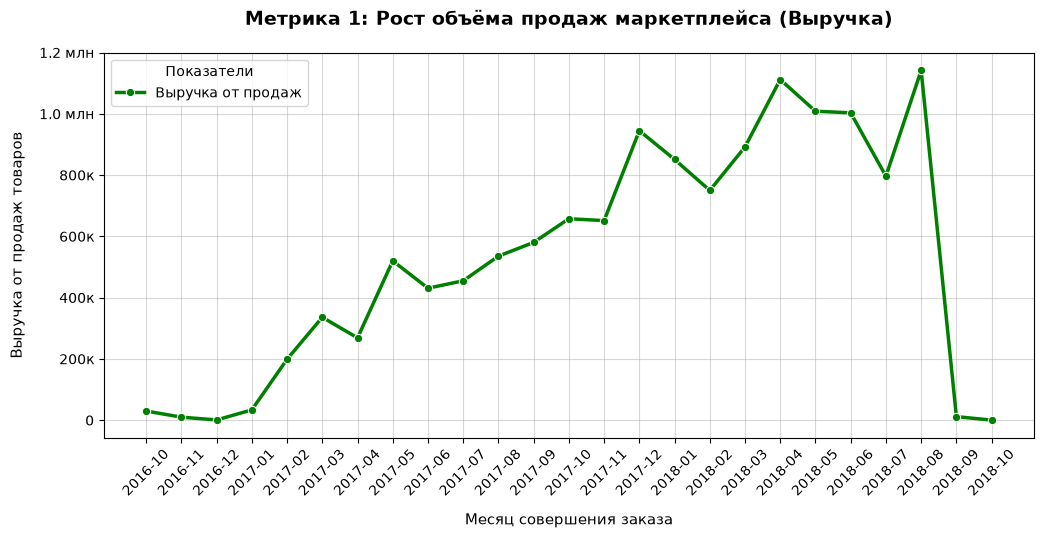

In [25]:
# Построим график вырчки
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=metric_1_GMV,
    x=metric_1_GMV["month"].astype(str),
    y="revenue_in_month",
    marker="o",
    linewidth=2.5,
    color = 'green',
    label="Выручка от продаж",
)

# 3. Добавляем бизнесовые подписи и заголовки
plt.title(
    "Метрика 1: Рост объёма продаж маркетплейса (Выручка)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.yticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000],
           ['0', '200к', '400к', '600к', '800к', '1.0 млн', '1.2 млн'])

plt.xlabel("Месяц совершения заказа", fontsize=11, labelpad=10)
plt.ylabel("Выручка от продаж товаров", fontsize=11, labelpad=10)


plt.xticks(rotation=45)


plt.grid(alpha=0.5)
plt.legend(title="Показатели")

# plt.savefig('Метрика_1_Выручка.png', dpi=300, bbox_inches='tight')

plt.show()


#### Метрика 2. Объем ценной аудитории: Количество уникальных клиентов с доставленными заказами за месяц (MAU)

In [26]:
# группируем уникальые айди клиентов по месяцам
metric_2_MAU = (df_metrics
 .groupby(['order_month'], as_index = False)
 .agg(customer_unique = ('customer_unique_id','nunique'))
 .rename(columns={'order_month':'month'}))

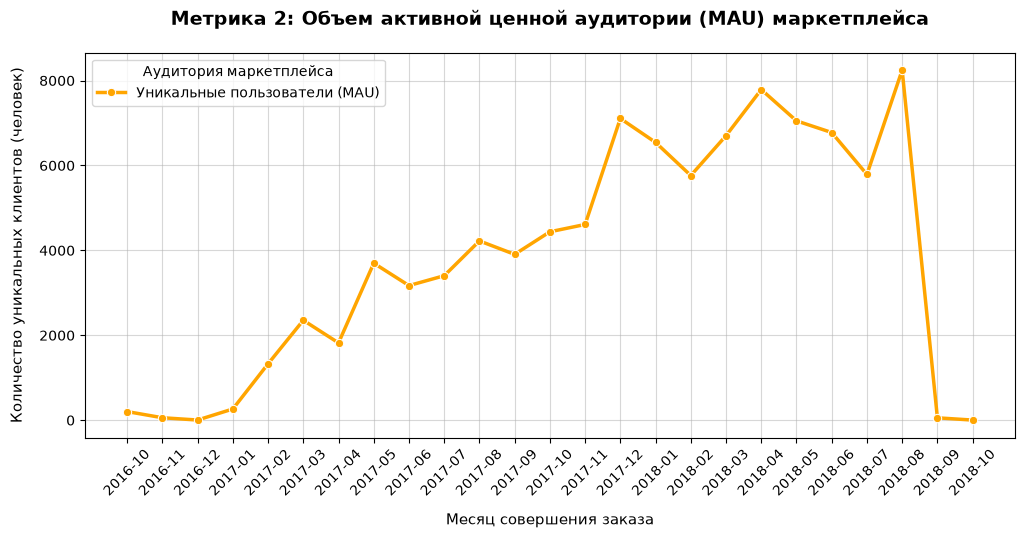

In [27]:
# Построю график MAU
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=metric_2_MAU,
    x=metric_2_MAU["month"].astype(str),  
    y="customer_unique", 
    marker="o",
    linewidth=2.5,
    color="orange",
    label="Уникальные пользователи (MAU)",
)


plt.title(
    "Метрика 2: Объем активной ценной аудитории (MAU) маркетплейса",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Месяц совершения заказа", fontsize=11, labelpad=10)
plt.ylabel("Количество уникальных клиентов (человек)", fontsize=11, labelpad=10)


plt.xticks(rotation=45)
plt.grid(alpha=0.5)
plt.legend(title='Аудитория маркетплейса')

# plt.savefig('Метрика_2_MAU.png', dpi=300, bbox_inches='tight')

plt.show()


/var/folders/2v/rh_f6dks70b1wj407db7x20c0000gn/T/ipykernel_18342/728020462.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(months_str, rotation=45)


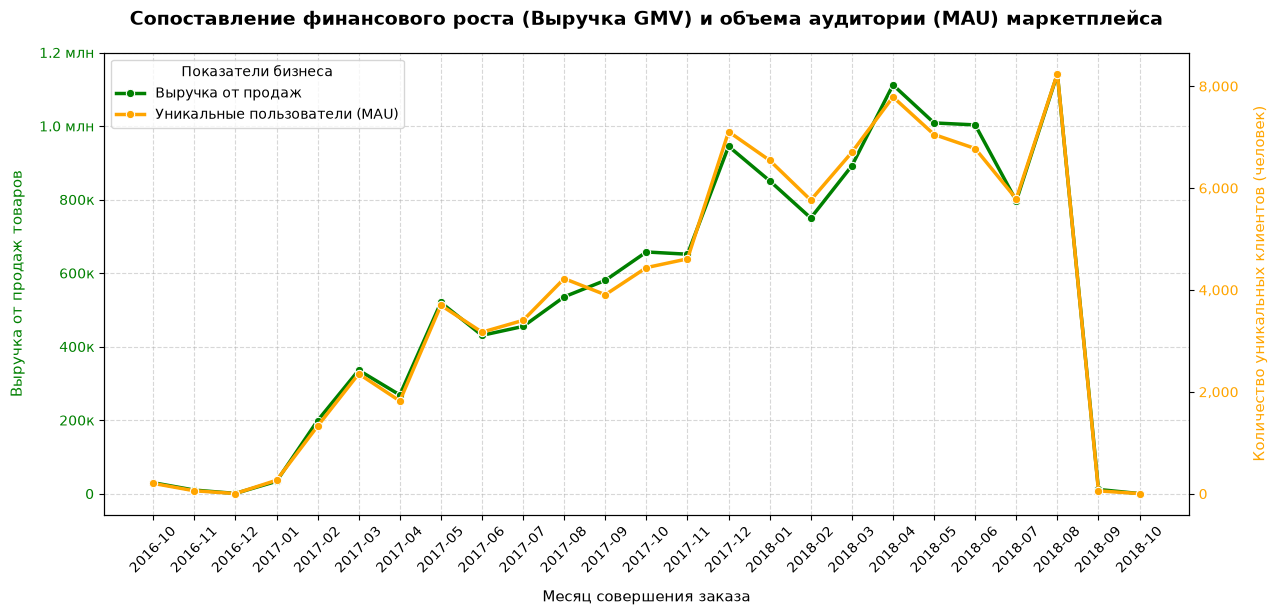

In [28]:
# объеденим графики для большей наглядности 

# 1. Создаем полотно
fig, ax1 = plt.subplots(figsize=(14, 6))

# Общая ось X для обоих графиков
months_str = metric_1_GMV["month"].astype(str)


# ПЕРВАЯ ОСЬ (ЛЕВАЯ): ВЫРУЧКА (Твой зеленый график)

color_revenue = 'green'
ax1.set_xlabel("Месяц совершения заказа", fontsize=11, labelpad=10)
ax1.set_ylabel("Выручка от продаж товаров", color=color_revenue, fontsize=11, labelpad=10)

# Строим зеленую линию выручки
sns.lineplot(
    data=metric_1_GMV,
    x=months_str,
    y="revenue_in_month",
    marker="o",
    linewidth=2.5,
    color=color_revenue,
    label="Выручка от продаж",
    ax=ax1
)
ax1.tick_params(axis='y', labelcolor=color_revenue)

# точные ручные деления шкалы рублей
ax1.set_yticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000])
ax1.set_yticklabels(['0', '200к', '400к', '600к', '800к', '1.0 млн', '1.2 млн'])

# ВТОРАЯ ОСЬ (ПРАВАЯ): MAU (Твой оранжевый график)

ax2 = ax1.twinx()  # Магия склейки осей

color_mau = 'orange'
ax2.set_ylabel("Количество уникальных клиентов (человек)", color=color_mau, fontsize=11, labelpad=10)

# Строим оранжевую линию MAU
sns.lineplot(
    data=metric_2_MAU,
    x=months_str,
    y="customer_unique",
    marker="o",
    linewidth=2.5,
    color=color_mau,
    label="Уникальные пользователи (MAU)",
    ax=ax2
)
ax2.tick_params(axis='y', labelcolor=color_mau)

# Автоматически форматируем ось человек с разделителем тысяч (например, 2,000 вместо 2000)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))

plt.title(
    "Сопоставление финансового роста (Выручка GMV) и объема аудитории (MAU) маркетплейса",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# поворот дат и включение сетки
ax1.set_xticklabels(months_str, rotation=45)
ax1.grid(True, linestyle="--", alpha=0.5)

# собираем легенду из двух разных осей в один левый верхний угол
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', title="Показатели бизнеса")
ax2.get_legend().remove() # Убираем дублирующуюся автолегенду


# plt.savefig('Объединенный_график_GMV_и_MAU.png', dpi=300, bbox_inches='tight')

plt.show()


In [29]:
# Проверим статистическую связь между количеством доставленных заказов и месячным GMV.
# Важно: высокая связь не означает причинность и не показывает вклад именно новых пользователей.

model = smf.ols('revenue_in_month ~ order_in_month', data=metric_1_GMV).fit()
# model.summary()

# R² ≈ 0.993: на доступных месячных данных число заказов очень тесно связано с GMV.
# Это ожидаемо для агрегированных метрик, но само по себе не доказывает причинно-следственную связь.

#### Метрика 3. Заинтересованность новых клиентов: Количество новых пользователей/установок приложения (New Users / Installs)

Для расчета этой метрики в датасете не хватает данных об установках приложения или первом визите пользователя. Поэтому корректно рассчитать New Users / Installs на имеющихся данных нельзя.

#### Метрика 4. (Вовлеченность/Частота покупок) : cколько в среднем заказов делает один уникальный клиент в  месяц

In [30]:
# Показывает, сколько в среднем заказов делает ОДИН уникальный клиент в этот месяц
metric_4_frequency = metric_1_GMV['order_in_month'] / metric_2_MAU['customer_unique']


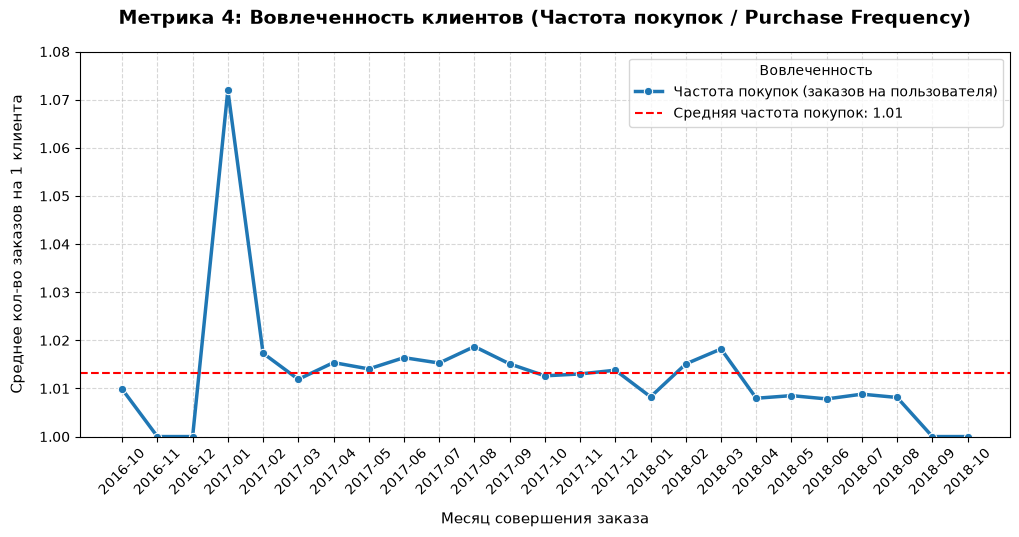

In [31]:
# Построю график среднее количество заказов на пользователя
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=metric_2_MAU["month"].astype(str),
    y=metric_4_frequency,
    marker="o",
    linewidth=2.5,
    label="Частота покупок (заказов на пользователя)",
)

plt.ylim(1.0, 1.08)


plt.title(
    "Метрика 4: Вовлеченность клиентов (Частота покупок / Purchase Frequency)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Месяц совершения заказа", fontsize=11, labelpad=10)
plt.ylabel("Среднее кол-во заказов на 1 клиента", fontsize=11, labelpad=10)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)


plt.axhline(metric_4_frequency.mean(), 
            linestyle = '--', 
            color = 'red', 
            label = f'Средняя частота покупок: {metric_4_frequency.mean():.3}')

plt.legend(title="Вовлеченность")

# plt.savefig('Метрика_4_Частота_покупок.png', dpi=300, bbox_inches='tight')

plt.show()

#### Метрика 5. Суммарная выручка на уникального пользователя за доступный период

В рамках учебного задания показатель обозначен как LTV. Фактически здесь рассчитывается историческая сумма покупок пользователя в пределах доступного периода наблюдения, поэтому ниже использую её как **приближение LTV**, а не как прогнозную пожизненную ценность клиента.

In [32]:
# Сгруппируем по уникальным клиентам и посчитаем сумму покупок каждого клиента
# за доступный период наблюдения. Возьмем медиану, чтобы снизить влияние выбросов.
# В учебном задании показатель обозначен как LTV; фактически это историческая
# накопленная выручка на клиента за период наблюдения.
metric_5_LTV = df_metrics.groupby('customer_unique_id')['price'].sum().median()
# metric_5_LTV

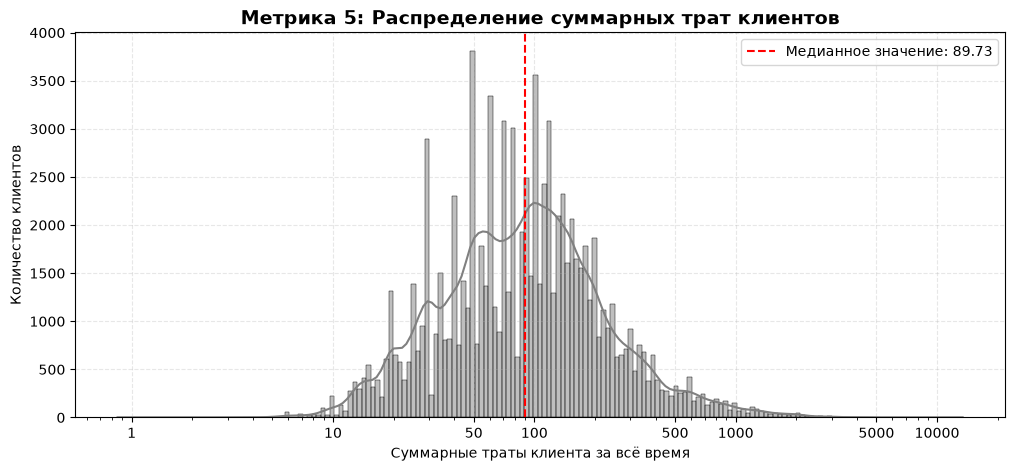

In [33]:
plt.figure(figsize=(12, 5))

# Передаем параметр log_scale=True прямо в гистограмму
sns.histplot(data = df_metrics.groupby('customer_unique_id')['price'].sum(), color="gray", log_scale=True, kde=True)

plt.title("Метрика 5: Распределение суммарных трат клиентов", fontsize=14, fontweight="bold")
plt.xlabel("Суммарные траты клиента за всё время")
plt.ylabel("Количество клиентов")

plt.xticks([1, 10, 50, 100, 500, 1000, 5000, 10000],
           ['1','10','50','100','500', '1000','5000','10000'])

plt.axvline(metric_5_LTV, linestyle = '--', color = 'red', label = f'Медианное значение: {metric_5_LTV:.2f}')


plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

# plt.savefig('Метрика_5_LTV.png', dpi=300, bbox_inches='tight')


plt.show()


<a id="task-4"></a>
### Часть 4: Приоритизация бэклога разработки по фреймворку ICE

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

In [34]:
# медианный retention 1-го месяца = 0.0035
# retention_first_month

#### Гипотеза 1
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [35]:
# возьму датасет с заказами. отфильтрую >= 2017-04. посчитаю value_counts отмененных заказов. 
# их сумма и будет приростом
impact_1 = orders[orders.order_purchase_timestamp >= '2017-06-01'].order_status.value_counts()[['canceled','unavailable']].sum()
# impact_1

# 974 соответвует 5 баллам по шкале impact
ice_1 = 5*8*6

#### Гипотеза 2

Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

In [36]:
# считаем количество доставленных заказов у которых значение разницы ожидаемой 
# и фактической доставки отрицательное.
# умножаем количево на ретеншен  месяца
# это будет потенциальное количесво заказов плюсом

impact_2 = orders[(orders.order_purchase_timestamp >= '2017-06-01')
                  &(orders.order_status == 'delivered')]
impact_2['delay_orders_day']= (((pd.to_datetime(impact_2.order_estimated_delivery_date) - 
                                pd.to_datetime(impact_2.order_delivered_customer_date)).dt.days))
impact_2 = impact_2[impact_2.delay_orders_day < 0]['order_id'].nunique() * retention_first_month

impact_2.round() 

# 26 человек соответсвует 1 баллу по шкале
ice_2 = 1*10*4

#### Гипотеза 3

Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [37]:
# ищем уникальные кастомер айди, у котрых только 1 заказ. их количево умножаем на медианный ретеншен 1 месяца
df_impact_3 = orders.merge(customers[['customer_id','customer_unique_id']], on  = 'customer_id', how = 'left')
impact_3 = df_impact_3[df_impact_3.order_purchase_timestamp > '2017-06-01'].groupby('customer_unique_id', as_index = False)['order_id'].nunique().sort_values('order_id')
impact_3 = impact_3[impact_3.order_id == 1]['order_id'].count()*retention_first_month

# 82559 - толко 1 заказ
impact_3.round()
# 289 соответвует 3 баллам по шкале impact
ice_3 = 3*5*9

### Таблица приоритезации гипотез по фреймворку ICE

| Гипотеза | Impact | Confidence | Ease | Итоговый балл ICE | Приоритет |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **1. Исправление багов в системе процессинга заказов** (избавление от отмен) | 5 | 8 | 6 | **240** | **1 (Победитель)** |
| **3. Создание нового способа оплаты** (упрощение чекаута для новых) | 3 | 5 | 9 | **135** | **2** |
| **2. Сокращение времени до отгрузки** (борьба с опозданиями доставки) | 1 | 10 | 4 | **40** | **3** |

**Вывод:** 
Однозначным победителем приоритезации становится **Гипотеза №1**. Несмотря на то, что разработка имеет среднюю сложность (Ease = 6), она обладает самым мощным балансом высокого потенциального влияния на объём доставленных заказов (Impact = 5) и высокой уверенности команды в успехе (Confidence = 8). Данная задача рекомендуется к первоочередному включению в бэклог разработки маркетплейса.


<a id="task-5"></a>
### Часть 5: Проектирование архитектуры и метрик A/B-теста

 Для проверки эффективности исправления багов в системе процессинга заказов (Гипотеза №1) сформирована следующая система метрик эксперимента:

1. **Целевая метрика (Primary Metric): GMV (Валовой оборот маркетплейса в деньгах)**
   * *Обоснование:* Конечный успех эксперимента для бизнеса всегда измеряется финансово. Избавление от системных отмен позволит довести больше сделок до финального статуса `delivered`, что напрямую увеличит общую сумму проданных товаров и максимизирует прибыль компании.

2. **Прокси-метрики (Proxy Metrics): Количество доставленных заказов и Процент отмен (Cancellation Rate)**
   * *Обоснование:* Данные метрики отражают непосредственный технический эффект от исправления багов процессинга, изолируя результат эксперимента от влияния внешних рыночных факторов на итоговый GMV. Мы ожидаем увидеть мгновенное снижение процента отменённых заказов и пропорциональный рост физического объёма доставок на тестовой группе.

3. **Барьерные метрики (Guardrail Metrics): DAU и Конверсия верхних этапов воронки (Заход -> Корзина -> Создание заказа)**
   * *Обоснование:* Это метрики здоровья продукта, которые мы боимся случайно ухудшить. Масштабное вмешательство в код бэкенда процессинга несёт риски критических сбоев. Мы обязаны следить, чтобы технические работы не уронили ежедневную аудиторию (DAU) и не сломали логику чекаута на ранних этапах воронки до момента оплаты.



<a id="final-report"></a>
> ## Итоговый аналитический отчет для менеджмента


### 1. Формализация проблемы продукта
Выручка маркетплейса стоит на месте уже несколько месяцев. Чтобы разобраться в возможных причинах стагнации, мы разложили верхнеуровневые показатели бизнеса на составляющие: провели когортный анализ, рассчитали выручку по месяцам (GMV), определили ежемесячную активную аудиторию (MAU), частоту покупок на одного клиента и историческую накопленную выручку на клиента за доступный период.

Исследование показало прежде всего проблему с удержанием: большинство пользователей совершает один заказ и не возвращается в следующие месяцы. Это является важным сигналом для проверки продуктовых гипотез и дальнейшей оценки Product-Market Fit, однако только этих данных недостаточно, чтобы однозначно доказать наличие или отсутствие PMF.

### 2. Общие выводы по итогу исследования

> Был проведён когортный анализ. **Retention Rate 1-го месяца** для большинства когорт остается ниже 1%. Медианный retention 1-го месяца равен **0.35%**, а максимальное значение retention на 3-й месяц в рассматриваемых данных составляет **0.56%**. Это указывает на низкую долю повторных покупок и необходимость отдельно исследовать причины оттока.

![Когортный_анализ_Monthly_Retention_Rate.png](images/Когортный_анализ_Monthly_Retention_Rate.png)

![Retention_1_месяца.png](images/Retention_1_месяца.png)

![Retention_3_месяца.png](images/Retention_3_месяца.png)

> На примере 5 крупнейших когорт видно, что удержание после первого заказа остается низким, а выраженного плато retention на доступном горизонте наблюдения не формируется.

![Кривые_оттока_клиентов.png](images/Кривые_оттока_клиентов.png)

> Чтобы оценить финансовое состояние продукта на текущий момент, мы проанализировали продуктовую матрицу метрик:

![GMV_MAU.png](images/GMV_MAU.png)

> При сопоставлении месячного GMV и количества доставленных заказов наблюдается очень сильная линейная связь: OLS-модель дает **R² ≈ 0.993**. Это означает, что на доступных агрегированных данных изменение GMV тесно связано с изменением числа заказов, но не доказывает причинность и не позволяет отдельно оценить вклад новых пользователей. График частоты покупок также показывает, что на одного активного пользователя приходится в среднем около **1 заказа в месяц**.

![Метрика_4_Частота_покупок.png](images/Метрика_4_Частота_покупок.png)

> Низкая частота повторных покупок согласуется с результатами когортного анализа: маркетплейс в значительной степени опирается на однократные покупки.
>
> Медианная сумма покупок одного уникального клиента за доступный период составляет **89.73**. В рамках учебного задания она используется как приближение LTV, однако корректнее трактовать её как историческую накопленную выручку на клиента за период наблюдения.

![Метрика_5_LTV.png](images/Метрика_5_LTV.png)

> Для вывода о допустимой стоимости привлечения (CAC) одной этой величины недостаточно: необходимо учитывать маржинальность, стоимость обслуживания, горизонт наблюдения и прогноз повторных покупок.

Таким образом, собранные метрики указывают прежде всего на **проблему удержания и повторных покупок**. Перед масштабированием продукта стоит подробнее исследовать причины оттока, экономику привлечения и пользовательский опыт.

### 3. Приоритезация гипотез для дальнейшего анализа

> С помощью фреймворка ICE мы выбрали гипотезу для дальнейшего анализа.

| Гипотеза | Impact | Confidence | Ease | Итоговый балл ICE | Приоритет |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **1. Исправление багов в системе процессинга заказов** (избавление от отмен) | 5 | 8 | 6 | **240** | **1 (Победитель)** |
| **3. Создание нового способа оплаты** (упрощение чекаута для новых) | 3 | 5 | 9 | **135** | **2** |
| **2. Сокращение времени до отгрузки** (борьба с опозданиями доставки) | 1 | 10 | 4 | **40** | **3** |

> Мы полагаем, что после исправления бага с процессингом мы **избавимся от технических отмен заказов**. За исследуемый период количество отмененных заказов составило **974**. Данная гипотеза выбрана как приоритетная для оперативной стабилизации выручки
> 
 Для проверки эффективности исправления багов в системе процессинга заказов *(Гипотеза №1)* сформирована следующая система метрик эксперимента:

1. **Целевая метрика (Primary Metric): GMV (Валовой оборот маркетплейса в деньгах)**
   * *Обоснование:* Конечный успех эксперимента для бизнеса всегда измеряется финансово. Избавление от системных отмен позволит довести больше сделок до финального статуса `delivered`, что напрямую увеличит общую сумму проданных товаров и максимизирует прибыль компании.  
   

2. **Прокси-метрики (Proxy Metrics): Количество доставленных заказов и Процент отмен (Cancellation Rate)**
   * *Обоснование:* Данные метрики отражают непосредственный технический эффект от исправления багов процессинга, изолируя результат эксперимента от влияния внешних рыночных факторов на итоговый GMV. Мы ожидаем увидеть мгновенное снижение процента отменённых заказов и пропорциональный рост физического объёма доставок на тестовой группе.  
   

3. **Барьерные метрики (Guardrail Metrics): DAU и Конверсия верхних этапов воронки (Заход -> Корзина -> Создание заказа)**
   * *Обоснование:* Это метрики здоровья продукта, которые мы боимся случайно ухудшить. Масштабное вмешательство в код бэкенда процессинга несёт риски критических сбоев. Мы обязаны следить, чтобы технические работы не уронили ежедневную аудиторию (DAU) и не сломали логику чекаута на ранних этапах воронки до момента оплаты.


### 4. Рекомендации по продукту

> С учётом низкого удержания маркетплейсу стоит сначала подробнее исследовать причины оттока, а затем принимать решение о масштабировании маркетинговых расходов. Продуктовой команде можно запустить цикл проверки гипотез и провести аудит ключевых точек отказа:
> * **Логистика**: анализ SLA доставки и работы курьерских служб;
> * **Продукт**: технический аудит платформы и UX-анализ интерфейсов;
> * **Рынок**: анализ ассортимента и факторов повторной покупки.
>
> Внедрение системы оценивания заказов и доставки, а также исследование клиентского опыта позволят получить дополнительные данные для дальнейшего анализа.